In [1]:
import os

In [2]:
%pwd

'd:\\Coding\\Data science\\Smart-Inventory-Defect-Detection-Quality-Control-API\\research'

In [3]:
os.chdir('../')

In [4]:
%pwd

'd:\\Coding\\Data science\\Smart-Inventory-Defect-Detection-Quality-Control-API'

In [31]:
from dataclasses import dataclass
from pathlib import Path

@dataclass(frozen=True)
class EDAConfig:
    train_csv: Path
    train_images_path: Path
    test_images_path: Path
    height: int
    width: int
    num_classes: int
    order: str

In [32]:
from SIDD.utils.common import read_yaml, create_directories
from SIDD.constants import *

In [33]:
class ConfigurationManager:
    def __init__(
        self,
        config_filepath = CONFIG_FILE_PATH,
        params_filepath = PARAMS_FILE_PATH,):

        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)
        create_directories([self.config.artifacts_root])

    def get_eda_config(self) -> EDAConfig:
        config = self.config.data

        eda_config = EDAConfig(
            train_csv=config.train_csv,
            train_images_path=config.train_images_path,
            test_images_path=config.test_images_path,
            height=self.config.image.height,
            width=self.config.image.width,
            num_classes=self.config.image.num_classes,
            order=self.config.rle.order
        )

        return eda_config


In [34]:
from SIDD import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import cv2

In [69]:
class EDA:
    def __init__(self, config: EDAConfig):
        self.config = config
        self.df = None

    def load_data(self):
        self.df = pd.read_csv(self.config.train_csv)
        return self.df
        
    def rle_decode(self, mask_rle, shape):
        s = mask_rle.split()

        starts = np.asarray(s[0::2], dtype=int) - 1
        lengths = np.asarray(s[1::2], dtype=int)

        ends = starts + lengths

        img = np.zeros(shape[0] * shape[1], dtype=np.uint8)

        for start, end in zip(starts, ends):
            img[start:end] = 1

        return img.reshape(shape, order='F')

    def load_image(self, image_id):
        image_path = Path(self.config.train_images_path) / image_id

        image = cv2.imread(str(image_path))

        if image is None:
            raise FileNotFoundError(f"Image not found: {image_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        return image

    def create_multi_mask(self, image_id):
        mask = np.zeros((self.config.height, self.config.width, self.config.num_classes), dtype=np.uint8)

        group = self.df.groupby("ImageId").get_group(image_id)

        for _, row in group.iterrows():
            class_id = row["ClassId"]
            rle = row["EncodedPixels"]

            if pd.isna(rle):
                continue

            single_mask = self.rle_decode(rle, (self.config.height, self.config.width))

            mask[:, :, class_id - 1] = single_mask

        return mask

    
    def visualize_multiclass_overlay(self, image, multi_mask):
        plt.figure(figsize=(10, 5))
        plt.imshow(image)

        colors = ["Reds", "Blues", "Greens", "Purples"]

        for i in range(multi_mask.shape[-1]):
            plt.imshow(multi_mask[:, :, i], cmap=colors[i], alpha=0.4)

        plt.axis("off")
        plt.show()

[2026-06-22 16:22:03,274: INFO: common: yaml file: config\config.yaml loaded successfully]
[2026-06-22 16:22:03,277: INFO: common: yaml file: params.yaml loaded successfully]
[2026-06-22 16:22:03,278: INFO: common: created directory at: artifacts]


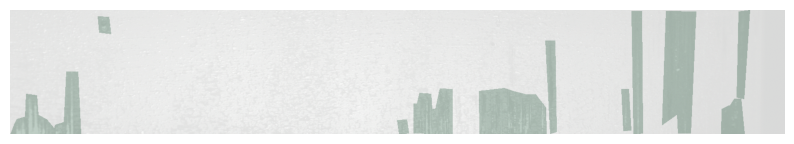

In [70]:
try:
    config_manager = ConfigurationManager()
    eda_config = config_manager.get_eda_config()

    eda = EDA(config=eda_config)

    df = eda.load_data()

    image_id = df["ImageId"].iloc[50]

    image = eda.load_image(image_id)
    mask = eda.create_multi_mask(image_id)
    eda.visualize_multiclass_overlay(image, mask)

except Exception as e:
    raise e